### ```Diabetes Predictions```

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [61]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes()

In [62]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [63]:
import pandas as pd
df_diabetes=pd.DataFrame(dataset.data,columns=['age',
  'sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [64]:
## Independent and dependent features
X = df_diabetes
y = dataset['target']

In [65]:
## train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [66]:
## correlation
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.171161,0.184695,0.314569,0.270283,0.218952,-0.043783,0.180038,0.268422,0.281806
sex,0.171161,1.000000,0.033934,0.179283,0.021069,0.120205,-0.355094,0.320490,0.113187,0.165951
bmi,0.184695,0.033934,1.000000,0.394309,0.266467,0.261560,-0.354655,0.430974,0.468473,0.404928
bp,0.314569,0.179283,0.394309,1.000000,0.239978,0.161457,-0.120827,0.212785,0.375295,0.374647
s1,0.270283,0.021069,0.266467,0.239978,1.000000,0.891063,0.053003,0.546840,0.528543,0.330773
s2,0.218952,0.120205,0.261560,0.161457,0.891063,1.000000,-0.190658,0.654675,0.307139,0.293291
s3,-0.043783,-0.355094,-0.354655,-0.120827,0.053003,-0.190658,1.000000,-0.736685,-0.372437,-0.288236
s4,0.180038,0.320490,0.430974,0.212785,0.546840,0.654675,-0.736685,1.000000,0.613472,0.431352
s5,0.268422,0.113187,0.468473,0.375295,0.528543,0.307139,-0.372437,0.613472,1.000000,0.478967
s6,0.281806,0.165951,0.404928,0.374647,0.330773,0.293291,-0.288236,0.431352,0.478967,1.000000


<Axes: >

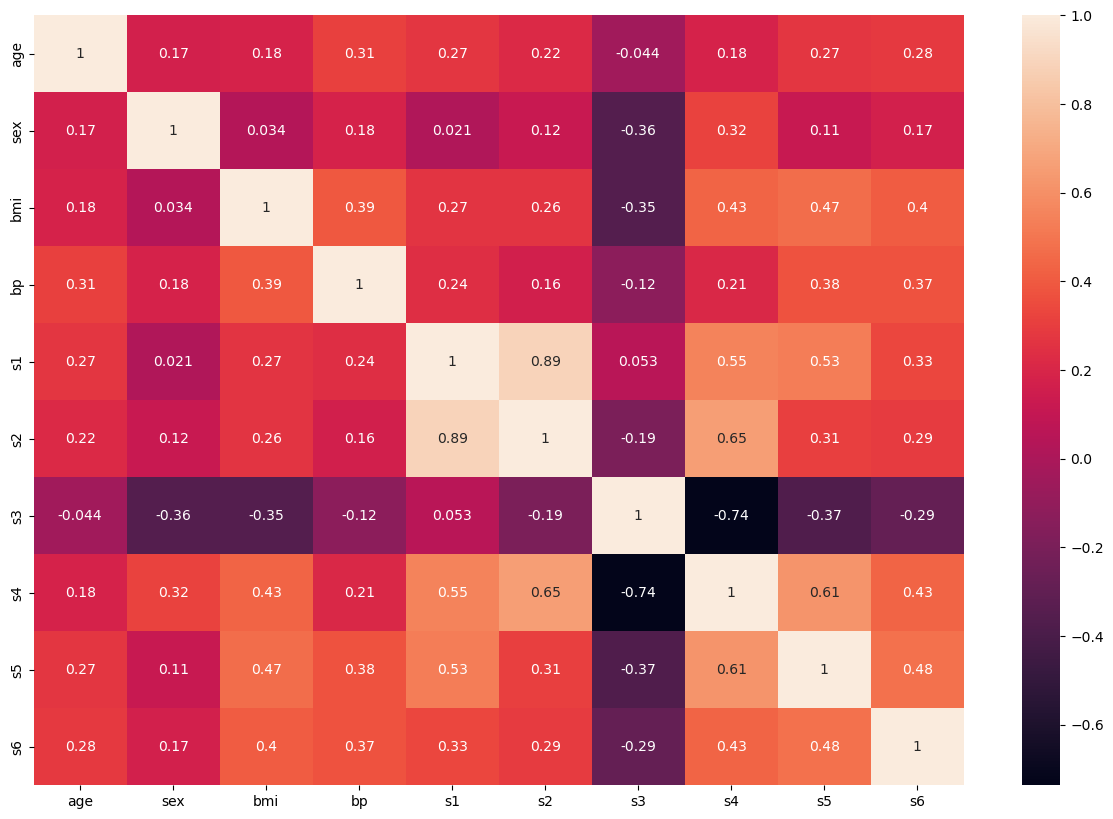

In [67]:
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [68]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [69]:
model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### ```Hyperparameter Tunning```

In [70]:
import warnings
warnings.filterwarnings("ignore")

In [71]:
params={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

In [74]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

In [75]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=5,
    scoring='neg_mean_squared_error',
   
)

grid.fit(X_train, y_train)

print('Best Parameters :', grid.best_params_)
print('Best Score      :', grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

Best Parameters : {'criterion': 'friedman_mse', 'max_depth': 5, 'max_features': 'log2', 'splitter': 'best'}
Best Score      : -4102.302714926989


In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

print('MAE      :', mean_absolute_error(y_test, y_pred))
print('MSE      :', mean_squared_error(y_test, y_pred))
print('RMSE     :', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score :', r2_score(y_test, y_pred))



MAE      : 46.08340104307862
MSE      : 3386.6246322681695
RMSE     : 58.19471309550524
R2 Score : 0.36079131119330987


[Text(0.4652777777777778, 0.9166666666666666, 'x[2] <= 0.005\nfriedman_mse = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.22685185185185186, 0.75, 'x[8] <= 0.006\nfriedman_mse = 3612.73\nsamples = 209\nvalue = 118.043'),
 Text(0.3460648148148148, 0.8333333333333333, 'True  '),
 Text(0.1388888888888889, 0.5833333333333334, 'x[6] <= 0.021\nfriedman_mse = 2378.339\nsamples = 152\nvalue = 100.559'),
 Text(0.07407407407407407, 0.4166666666666667, 'x[5] <= 0.091\nfriedman_mse = 2950.846\nsamples = 87\nvalue = 111.069'),
 Text(0.037037037037037035, 0.25, 'x[8] <= -0.043\nfriedman_mse = 2607.459\nsamples = 85\nvalue = 108.0'),
 Text(0.018518518518518517, 0.08333333333333333, 'friedman_mse = 1639.174\nsamples = 25\nvalue = 83.16'),
 Text(0.05555555555555555, 0.08333333333333333, 'friedman_mse = 2646.694\nsamples = 60\nvalue = 118.35'),
 Text(0.1111111111111111, 0.25, 'x[3] <= 0.024\nfriedman_mse = 132.25\nsamples = 2\nvalue = 241.5'),
 Text(0.09259259259259259, 0.08333333333333333, 'frie

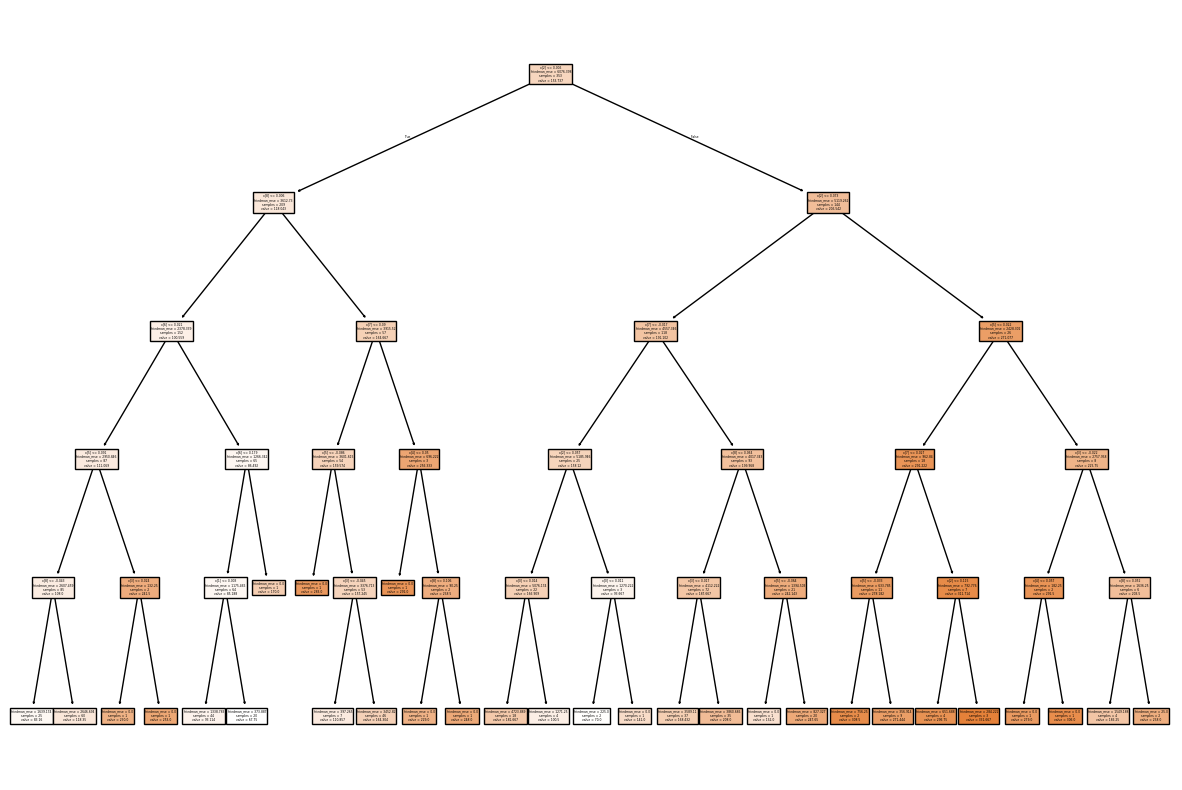

In [80]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(best_model,filled=True)